# Corrélation de Pearson

Corrélations fortes (|r| ≥ 0.30) :


corr
Achats_catalogue   Montant_viande       0.724611
Revenu             Achats_catalogue     0.693498
                   Montant_vin          0.686117
                   Montant_viande       0.684469
                   Nb_visites_web_mois -0.646191
...                                          ...
Montant_vin        Nb_visites_web_mois -0.320668
Achats_catalogue   Accepte_Campagne_5   0.318831
Montant_viande     Accepte_Campagne_1   0.311684
Accepte_Campagne_5 Accepte_Campagne_4   0.309086
Achats_catalogue   Accepte_Campagne_1   0.305446

[76 rows x 1 columns]

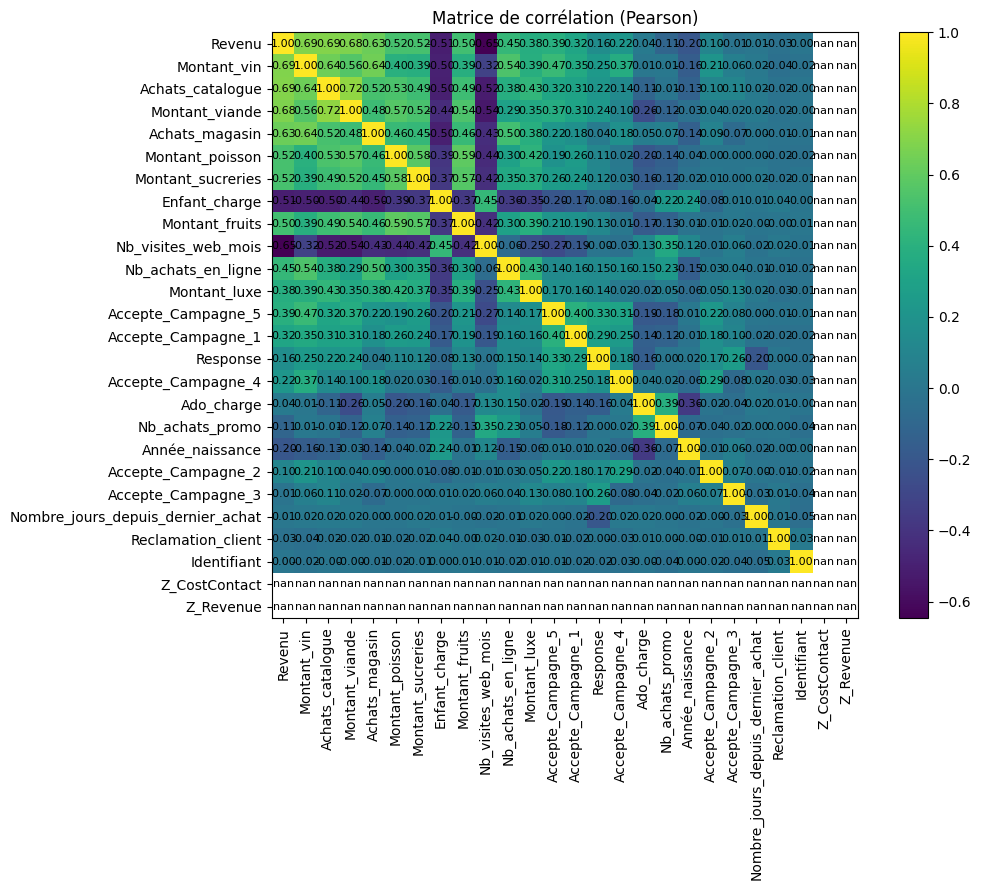

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# data
df = pd.read_csv("data/processed/camp_market_clean.csv")  # adapte si besoin
num = df.select_dtypes(include="number")

# pearson
corr = num.corr(method="pearson")

# ordonner les variables pour une heatmap plus lisible
order = corr.abs().sum().sort_values(ascending=False).index
corr = corr.loc[order, order]

# lister les corrélations fortes |r| >= 0.30 (triangulaire sup) 
thr = 0.30
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
strong_pairs = (
    upper.stack()
         .rename("corr")
         .loc[lambda s: s.abs() >= thr]
         .sort_values(key=lambda s: -s.abs())
)
print("Corrélations fortes (|r| ≥ 0.30) :")
display(strong_pairs.to_frame())

# heatmap matplotlib
fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr, interpolation="nearest")  # pas de colormap imposée
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(np.arange(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Matrice de corrélation (Pearson)")

# annotations numériques
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.tight_layout()
plt.show()
